# Incremental path: from Costa & Kwon (2020) to the RWLS framework

Each arm adds exactly one component to the previous one, so the contribution of
every methodological choice is the difference between consecutive arms.

| Arm | HMM emission | Loadings | Objective |
|---|---|---|---|
| `ck_uni` | univariate (Mkt-Rf) | hard classification, 24m | collapsed MVO |
| `ck_multi` | multivariate (6 factors) | hard classification, 24m | collapsed MVO |
| `rwls_mvo` | multivariate | RWLS, full sample | collapsed MVO |
| `rwls_mixture` | multivariate | RWLS, full sample | full mixture utility |

`ck_uni` reproduces the estimator of Costa & Kwon (2020); `rwls_mixture` is the
framework proposed in this paper.

All four arms estimate the HMM on the information set available at each
decision date and share a single implementation of the projection from factor
space to asset space, so the differences below are attributable to the three
components being varied and to nothing else.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import entropy

from regimeaware.constants import DataConstants, SimulationParameters

ARMS = ["ck_uni", "ck_multi", "rwls_mvo", "rwls_mixture"]

LABELS = {
    "ck_uni": r"Costa \& Kwon",
    "ck_multi": "+ multivariate HMM",
    "rwls_mvo": "+ RWLS",
    "rwls_mixture": "+ mixture utility",
}

STEPS = [
    ("ck_uni", "ck_multi", "Emission dimension"),
    ("ck_multi", "rwls_mvo", "RWLS estimator"),
    ("rwls_mvo", "rwls_mixture", "Mixture objective"),
]

PHI_LIST = [10, 25, 50]

plt.rcParams.update(
    {"text.usetex": True, "font.family": "serif", "font.sans-serif": ["CMU Serif"]}
)

## 1. Load weights and compute realised out-of-sample returns

In [2]:
from regimeaware.core.simdata import load_simulation

sec_rt, _ = load_simulation(
    SimulationParameters.TRIALS.value,
    SimulationParameters.NUM_STOCKS.value,
    DataConstants.WDIR.value,
)

wts = {a: pd.read_pickle(f"{DataConstants.WDIR.value}/results/{a}.pkl") for a in ARMS}

# Paths actually completed for every arm, so all comparisons are like-for-like
common = set.intersection(
    *[set(w.index.get_level_values("iteration").unique()) for w in wts.values()]
)
common = sorted(common)
print(f"paths available for every arm: {len(common)}")

paths available for every arm: 1000


In [3]:
def realised_returns(weights, iterations):
    """Portfolio returns from weights decided at t and earned at t+1."""
    out = {}
    for phi in PHI_LIST:
        w_phi = weights.xs(phi, level="phi")
        for i in iterations:
            w = w_phi.xs(i, level="iteration")
            out[(phi, i)] = w.shift(1).mul(sec_rt[i]).dropna(how="all").sum(axis=1)
    res = pd.DataFrame.from_dict(out, orient="index").sort_index()
    res.index.names = ["phi", "iteration"]
    return res


rets = {a: realised_returns(wts[a], common) for a in ARMS}

## 2. Per-path performance metrics

Computed path by path so that every statistic below carries a Monte Carlo
distribution rather than a single point estimate.

In [4]:
def path_metrics(returns, weights):
    """Table 2 statistics, one row per (phi, path)."""
    rows = {}
    for phi in PHI_LIST:
        w_phi = weights.xs(phi, level="phi")
        for i in returns.xs(phi, level="phi").index:
            r = pd.to_numeric(returns.loc[(phi, i)], errors="coerce").dropna()
            w = w_phi.xs(i, level="iteration").copy()
            w[w < 1e-4] = 0

            n = len(r)
            ann_ret = (1 + r).prod() ** (12 / n) - 1
            ann_vol = r.std() * np.sqrt(12)
            wealth = (1 + r).cumprod()
            var95 = np.percentile(r, 5)

            rows[(phi, i)] = {
                "Ann. Excess Return": ann_ret,
                "Ann. Std. Deviation": ann_vol,
                "Skewness": r.skew(),
                "Kurtosis": r.kurt(),
                "Sharpe Ratio": ann_ret / ann_vol,
                "Max. Drawdown": (wealth / wealth.cummax() - 1).min(),
                "Value-at-Risk (95%)": var95,
                "Expected Shortfall": r[r <= var95].mean(),
                "Portfolio Turnover": w.diff().abs().sum(axis=1).mean() * 12,
                "Avg. Num. Constituents": (w > 0).sum(axis=1).mean(),
                "Effective Num. Bets": w.apply(entropy, axis=1).apply(np.exp).mean(),
                # Certainty equivalent under the exponential utility actually
                # optimised, rather than its mean-variance approximation
                "Certainty Equivalent": -(1 / phi) * np.log(np.exp(-phi * r).mean()) * 12,
            }
    out = pd.DataFrame.from_dict(rows, orient="index")
    out.index.names = ["phi", "iteration"]
    return out


metrics = {a: path_metrics(rets[a], wts[a]) for a in ARMS}
print(metrics["rwls_mixture"].groupby("phi").mean().round(4).T)

phi                          10       25       50
Ann. Excess Return       0.8165   0.4706   0.2709
Ann. Std. Deviation      0.3249   0.2046   0.1342
Skewness                 1.6466   1.6401   1.6013
Kurtosis                 4.2932   4.4013   4.8076
Sharpe Ratio             2.4666   2.2948   2.0595
Max. Drawdown           -0.1291  -0.0829  -0.0624
Value-at-Risk (95%)     -0.0433  -0.0265  -0.0186
Expected Shortfall      -0.0736  -0.0468  -0.0340
Portfolio Turnover       3.4313   2.4282   1.7355
Avg. Num. Constituents  18.6030  36.3981  52.0977
Effective Num. Bets     13.1991  25.4572  35.9539
Certainty Equivalent     0.2761   0.0616  -0.0710


## 3. Main table: all arms, all risk aversion levels

This is the table that replaces Table 2 in the revision.

In [5]:
table = pd.concat(
    {LABELS[a]: metrics[a].groupby("phi").mean() for a in ARMS},
    names=["model"],
).swaplevel().sort_index()

table = table.T[[(phi, LABELS[a]) for phi in PHI_LIST for a in ARMS]]
table.round(4)

phi                               10                              \
model                  Costa \& Kwon + multivariate HMM   + RWLS   
Ann. Excess Return            0.5124             0.5555   0.6453   
Ann. Std. Deviation           0.2712             0.2556   0.2508   
Skewness                      1.2191             1.0361   1.1412   
Kurtosis                      4.2781             2.7013   2.6579   
Sharpe Ratio                  1.8547             2.1285   2.5581   
Max. Drawdown                -0.1694            -0.1477  -0.1188   
Value-at-Risk (95%)          -0.0529            -0.0521  -0.0428   
Expected Shortfall           -0.0908            -0.0819  -0.0683   
Portfolio Turnover            5.4061             7.4501   3.6607   
Avg. Num. Constituents       20.9340            17.2378  24.1439   
Effective Num. Bets          14.4461            11.9290  16.8334   
Certainty Equivalent          0.1303             0.1972   0.2737   

phi                                                 25                     \
model                  + mixture utility Costa \& Kwon + multivariate HMM   
Ann. Excess Return                0.8165        0.3060             0.3083   
Ann. Std. Deviation               0.3249        0.1818             0.1571   
Skewness                          1.6466        0.9347             0.7065   
Kurtosis                          4.2932        4.2063             2.3028   
Sharpe Ratio                      2.4666        1.6721             1.9516   
Max. Drawdown                    -0.1291       -0.1329            -0.1075   
Value-at-Risk (95%)              -0.0433       -0.0413            -0.0368   
Expected Shortfall               -0.0736       -0.0698            -0.0582   
Portfolio Turnover                3.4313        4.8222             6.5905   
Avg. Num. Constituents           18.6030       37.2225            30.3022   
Effective Num. Bets              13.1991       24.8023            20.3157   
Certainty Equivalent              0.2761       -0.1152            -0.0011   

phi                                                          50  \
model                    + RWLS + mixture utility Costa \& Kwon   
Ann. Excess Return       0.3266            0.4706        0.1931   
Ann. Std. Deviation      0.1411            0.2046        0.1340   
Skewness                 0.8735            1.6401        0.7093   
Kurtosis                 2.3998            4.4013        4.5091   
Sharpe Ratio             2.3624            2.2948        1.4416   
Max. Drawdown           -0.0782           -0.0829       -0.1149   
Value-at-Risk (95%)     -0.0271           -0.0265       -0.0340   
Expected Shortfall      -0.0440           -0.0468       -0.0577   
Portfolio Turnover       2.7229            2.4282        4.0983   
Avg. Num. Constituents  47.9223           36.3981       53.3853   
Effective Num. Bets     32.7672           25.4572       34.9403   
Certainty Equivalent     0.0778            0.0616       -0.2941   

phi                                                                   
model                  + multivariate HMM   + RWLS + mixture utility  
Ann. Excess Return                 0.1840   0.1745            0.2709  
Ann. Std. Deviation                0.1080   0.0900            0.1342  
Skewness                           0.5157   0.7137            1.6013  
Kurtosis                           2.4838   2.7671            4.8076  
Sharpe Ratio                       1.7254   2.0389            2.0595  
Max. Drawdown                     -0.0862  -0.0616           -0.0624  
Value-at-Risk (95%)               -0.0277  -0.0194           -0.0186  
Expected Shortfall                -0.0452  -0.0331           -0.0340  
Portfolio Turnover                 5.6325   2.1975            1.7355  
Avg. Num. Constituents            42.9351  65.5687           52.0977  
Effective Num. Bets               28.2221  44.5025           35.9539  
Certainty Equivalent              -0.1270  -0.0474           -0.0710

## 4. Incremental contributions

The difference between consecutive arms, paired path by path. Because every arm
sees the identical simulated return path, the pairing removes Monte Carlo noise
and the test is on the *difference*, which is far more powerful than comparing
two independent means.

In [6]:
def increment(metric, phi):
    """Paired difference for each step of the incremental path."""
    rows = []
    for lo, hi, name in STEPS:
        d = metrics[hi].xs(phi)[metric] - metrics[lo].xs(phi)[metric]
        t, p = stats.ttest_rel(metrics[hi].xs(phi)[metric], metrics[lo].xs(phi)[metric])
        _, p_w = stats.wilcoxon(d)
        rows.append(
            {
                "Step": name,
                "Delta": d.mean(),
                "Std. Err.": d.std() / np.sqrt(len(d)),
                "t-stat": t,
                "p (paired t)": p,
                "p (Wilcoxon)": p_w,
                "Frac. > 0": (d > 0).mean(),
            }
        )
    return pd.DataFrame(rows).set_index("Step")


for phi in PHI_LIST:
    print(f"\n{'='*72}\nSharpe ratio increments, phi = {phi}\n{'='*72}")
    print(increment("Sharpe Ratio", phi).round(4).to_string())


Sharpe ratio increments, phi = 10
                     Delta  Std. Err.   t-stat  p (paired t)  p (Wilcoxon)  Frac. > 0
Step                                                                                 
Emission dimension  0.2738     0.0152  18.0260           0.0           0.0      0.716
RWLS estimator      0.4297     0.0115  37.4878           0.0           0.0      0.884
Mixture objective  -0.0915     0.0058 -15.7119           0.0           0.0      0.282

Sharpe ratio increments, phi = 25
                     Delta  Std. Err.   t-stat  p (paired t)  p (Wilcoxon)  Frac. > 0
Step                                                                                 
Emission dimension  0.2795     0.0166  16.8052           0.0           0.0      0.703
RWLS estimator      0.4108     0.0118  34.9558           0.0           0.0      0.856
Mixture objective  -0.0676     0.0074  -9.1673           0.0           0.0      0.362

Sharpe ratio increments, phi = 50
                     Delta  Std. Er

## 5. Where the gain comes from

The decomposition Reviewer 3 asks for: the contribution of each component to
the total improvement over the Costa & Kwon benchmark.

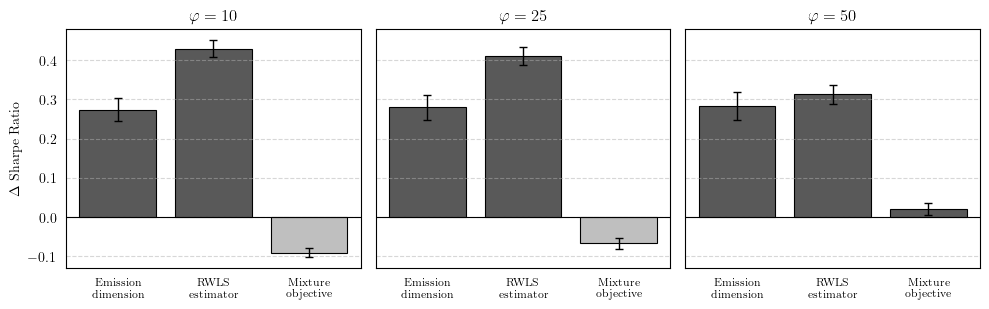

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), sharey=True)

for ax, phi in zip(axes, PHI_LIST):
    inc = increment("Sharpe Ratio", phi)
    colors = ["0.75" if d < 0 else "0.35" for d in inc["Delta"]]
    ax.bar(range(len(inc)), inc["Delta"], color=colors, edgecolor="k", lw=0.8)
    ax.errorbar(
        range(len(inc)),
        inc["Delta"],
        yerr=1.96 * inc["Std. Err."],
        fmt="none",
        ecolor="k",
        capsize=3,
        lw=1,
    )
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(range(len(inc)))
    ax.set_xticklabels(
        ["Emission\ndimension", "RWLS\nestimator", "Mixture\nobjective"], fontsize=8
    )
    ax.set_title(rf"$\varphi={phi}$")
    ax.grid(ls="--", alpha=0.5, axis="y", zorder=-25)
    ax.tick_params(bottom=False, left=False)

axes[0].set_ylabel("$\\Delta$ Sharpe Ratio")
plt.tight_layout()
plt.savefig(f"{DataConstants.WDIR.value}/img/ablation_increments.pdf", dpi=300, transparent=True)
plt.show()

## 6. Distribution of outcomes across arms

Stochastic dominance is what Figure 3 currently shows for two arms; here it is
extended to the full path so the reader can see whether each step shifts the
entire distribution or only its mean.

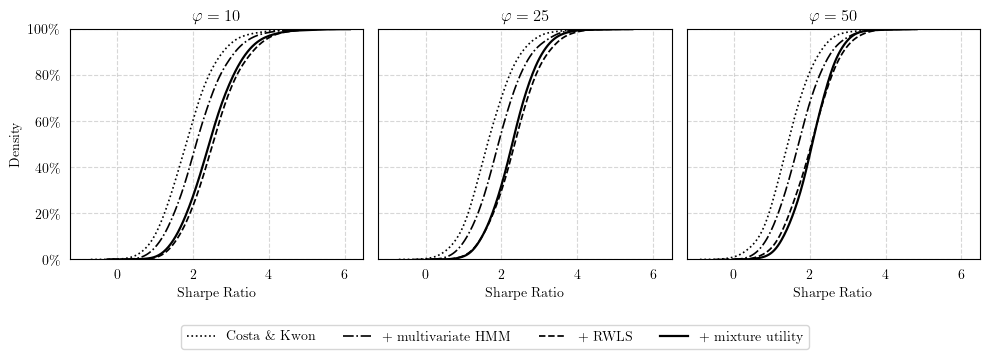

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), sharex=True, sharey=True)

styles = {
    "ck_uni": dict(ls=":", lw=1.2),
    "ck_multi": dict(ls="-.", lw=1.2),
    "rwls_mvo": dict(ls="--", lw=1.25),
    "rwls_mixture": dict(ls="-", lw=1.6),
}

for ax, phi in zip(axes, PHI_LIST):
    for a in ARMS:
        sns.kdeplot(
            data=metrics[a].xs(phi)["Sharpe Ratio"],
            cumulative=True, ax=ax, c="k", zorder=25,
            label=LABELS[a] if phi == PHI_LIST[0] else "",
            **styles[a],
        )
    ax.set_title(rf"$\varphi={phi}$")
    ax.set_xlabel("Sharpe Ratio")
    ax.grid(ls="--", alpha=0.5, zorder=-25)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0, 1)
    ax.tick_params(bottom=False, left=False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.13), ncol=4, frameon=True)
plt.tight_layout()
plt.savefig(f"{DataConstants.WDIR.value}/img/ablation_ecdf.pdf", dpi=300,
            transparent=True, bbox_inches="tight")
plt.show()

## 7. Behaviour across risk aversion

Reviewer 3's fourth point: the advantage is not uniform in $\varphi$. Plotting
every arm across the full grid of $\varphi$ shows where each component's
contribution concentrates.

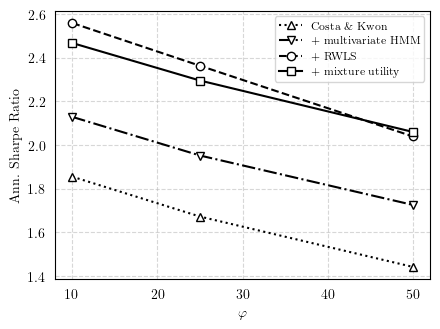

In [9]:
all_phis = list(SimulationParameters.RISK_AVERSION.value)

fig, ax = plt.subplots(figsize=(4.5, 3.4))
markers = {"ck_uni": "^", "ck_multi": "v", "rwls_mvo": "o", "rwls_mixture": "s"}

for a in ARMS:
    sr = metrics[a]["Sharpe Ratio"].groupby("phi").mean()
    ax.plot(sr.index, sr.values, c="k", marker=markers[a], markerfacecolor="white",
            markeredgewidth=1, label=LABELS[a], **{k: v for k, v in styles[a].items() if k != "lw"})

ax.set_xlabel(r"$\varphi$")
ax.set_ylabel("Ann. Sharpe Ratio")
ax.grid(ls="--", alpha=0.5, zorder=-25)
ax.tick_params(bottom=False, left=False)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{DataConstants.WDIR.value}/img/ablation_phi.pdf", dpi=300, transparent=True)
plt.show()

## 8. Significance of every metric against the Costa & Kwon benchmark

Reviewer 2 asks for the statistical significance of the reported measures
relative to the benchmark, not only the Sharpe ratio.

In [10]:
def significance_vs(base, phi):
    """Paired tests of every metric against a reference arm."""
    rows = {}
    for a in ARMS:
        if a == base:
            continue
        for m in metrics[a].columns:
            x, y = metrics[a].xs(phi)[m], metrics[base].xs(phi)[m]
            t, p = stats.ttest_rel(x, y)
            rows[(LABELS[a], m)] = {
                "Mean": x.mean(),
                "Delta": (x - y).mean(),
                "t-stat": t,
                "p-value": p,
            }
    out = pd.DataFrame.from_dict(rows, orient="index")
    out.index.names = ["model", "metric"]
    return out


for phi in PHI_LIST:
    print(f"\n{'='*72}\nAll metrics vs. Costa & Kwon, phi = {phi}\n{'='*72}")
    print(significance_vs("ck_uni", phi).round(4).to_string())


All metrics vs. Costa & Kwon, phi = 10
                                              Mean   Delta   t-stat  p-value
model              metric                                                   
+ multivariate HMM Ann. Excess Return       0.5555  0.0432   9.8535   0.0000
                   Ann. Std. Deviation      0.2556 -0.0156  -9.1304   0.0000
                   Skewness                 1.0361 -0.1830  -5.8364   0.0000
                   Kurtosis                 2.7013 -1.5768 -11.3671   0.0000
                   Sharpe Ratio             2.1285  0.2738  18.0260   0.0000
                   Max. Drawdown           -0.1477  0.0217   8.3573   0.0000
                   Value-at-Risk (95%)     -0.0521  0.0008   1.5555   0.1202
                   Expected Shortfall      -0.0819  0.0090   7.7485   0.0000
                   Portfolio Turnover       7.4501  2.0440  31.7985   0.0000
                   Avg. Num. Constituents  17.2378 -3.6962 -28.3967   0.0000
                   Effective Num. Be

## 9. Diagnosing the mixture objective

The mixture step is the one result that needs care in writing up, for two
reasons.

First, it is judged here on a criterion it does not optimise. Optimising over
the full mixture maximises expected exponential utility, not the Sharpe ratio,
so the two metrics need not agree — and they do not.

Second, its effect on the certainty equivalent has a positive median and a
negative mean at higher risk aversion: it helps on roughly two thirds of paths
and loses heavily on a minority. A mean-based test therefore rejects in the
opposite direction to a sign test, and reporting either alone would misdescribe
the result.

In [11]:
diag = {}
for phi in PHI_LIST:
    d_sr = metrics["rwls_mixture"].xs(phi)["Sharpe Ratio"] - metrics["rwls_mvo"].xs(phi)["Sharpe Ratio"]
    d_ce = metrics["rwls_mixture"].xs(phi)["Certainty Equivalent"] - metrics["rwls_mvo"].xs(phi)["Certainty Equivalent"]
    for name, d in [("Sharpe Ratio", d_sr), ("Certainty Equivalent", d_ce)]:
        diag[(phi, name)] = {
            "Mean": d.mean(),
            "Median": d.median(),
            "Frac. > 0": (d > 0).mean(),
            "p (sign)": stats.binomtest((d > 0).sum(), len(d), 0.5).pvalue,
            "5th pct": d.quantile(0.05),
            "95th pct": d.quantile(0.95),
        }

diag = pd.DataFrame.from_dict(diag, orient="index")
diag.index.names = ["phi", "metric"]
print(diag.round(4).to_string())

                            Mean  Median  Frac. > 0  p (sign)  5th pct  95th pct
phi metric                                                                      
10  Sharpe Ratio         -0.0915 -0.0798      0.282    0.0000  -0.3969    0.1915
    Certainty Equivalent  0.0024  0.0104      0.652    0.0000  -0.0741    0.0524
25  Sharpe Ratio         -0.0676 -0.0661      0.362    0.0000  -0.4512    0.3073
    Certainty Equivalent -0.0163  0.0100      0.676    0.0000  -0.1986    0.0504
50  Sharpe Ratio          0.0206  0.0128      0.515    0.3591  -0.3942    0.4373
    Certainty Equivalent -0.0236  0.0073      0.687    0.0000  -0.3403    0.0913


In [12]:
# Where the mixture objective moves the portfolio: it trades along the frontier
# rather than shifting it outward.
frontier = pd.DataFrame(
    {
        arm: metrics[arm][["Ann. Excess Return", "Ann. Std. Deviation"]]
        .groupby("phi")
        .mean()
        .stack()
        for arm in ["rwls_mvo", "rwls_mixture"]
    }
)
print("\n" + frontier.round(4).to_string())


                         rwls_mvo  rwls_mixture
phi                                            
10  Ann. Excess Return     0.6453        0.8165
    Ann. Std. Deviation    0.2508        0.3249
25  Ann. Excess Return     0.3266        0.4706
    Ann. Std. Deviation    0.1411        0.2046
50  Ann. Excess Return     0.1745        0.2709
    Ann. Std. Deviation    0.0900        0.1342


## 10. Comparison against the cached results

The cached `model.pkl` was produced by the original pipeline. It differs from
`rwls_mixture` in three ways at once, so the gap below is **not** interpretable
as the value of any one of them:

1. it supplies the optimiser with the true HMM parameters rather than
   estimating them on the information set available at each decision date;
2. it uses full-sample smoothed regime probabilities, which embed data from
   after the decision date;
3. it scales every covariance matrix by 1.5 through an operator-precedence
   error, which shifts the effective risk aversion away from the stated
   $\varphi$.

The comparison becomes interpretable only once (3) is corrected and the two
pipelines differ solely in their information set. Until then, treat the number
below as a diagnostic that the arms are not yet reconciled, not as a result.

In [13]:
try:
    cached = pd.read_pickle(f"{DataConstants.WDIR.value}/results/model.pkl")
    cached_rets = realised_returns(cached, common)
    cached_metrics = path_metrics(cached_rets, cached)

    comp = pd.DataFrame(
        {
            "cached (oracle regimes)": cached_metrics["Sharpe Ratio"].groupby("phi").mean(),
            "rwls_mixture (estimated)": metrics["rwls_mixture"]["Sharpe Ratio"].groupby("phi").mean(),
        }
    )
    comp["difference"] = comp.iloc[:, 0] - comp.iloc[:, 1]
    print(comp.round(4).to_string())
except FileNotFoundError:
    print("cached model.pkl not found; skipping")

     cached (oracle regimes)  rwls_mixture (estimated)  difference
phi                                                               
10                    2.4057                    2.4666     -0.0609
25                    2.1096                    2.2948     -0.1852
50                    1.6631                    2.0595     -0.3964
